### Preprocessing

In [1]:
from PIL import Image
from matplotlib.image import imread
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random
from skimage import exposure
from sklearn.utils import shuffle

In [4]:
data_dir = "gtsrb"
train_dir = data_dir + "/Train"
test_dir = data_dir + "/Test"

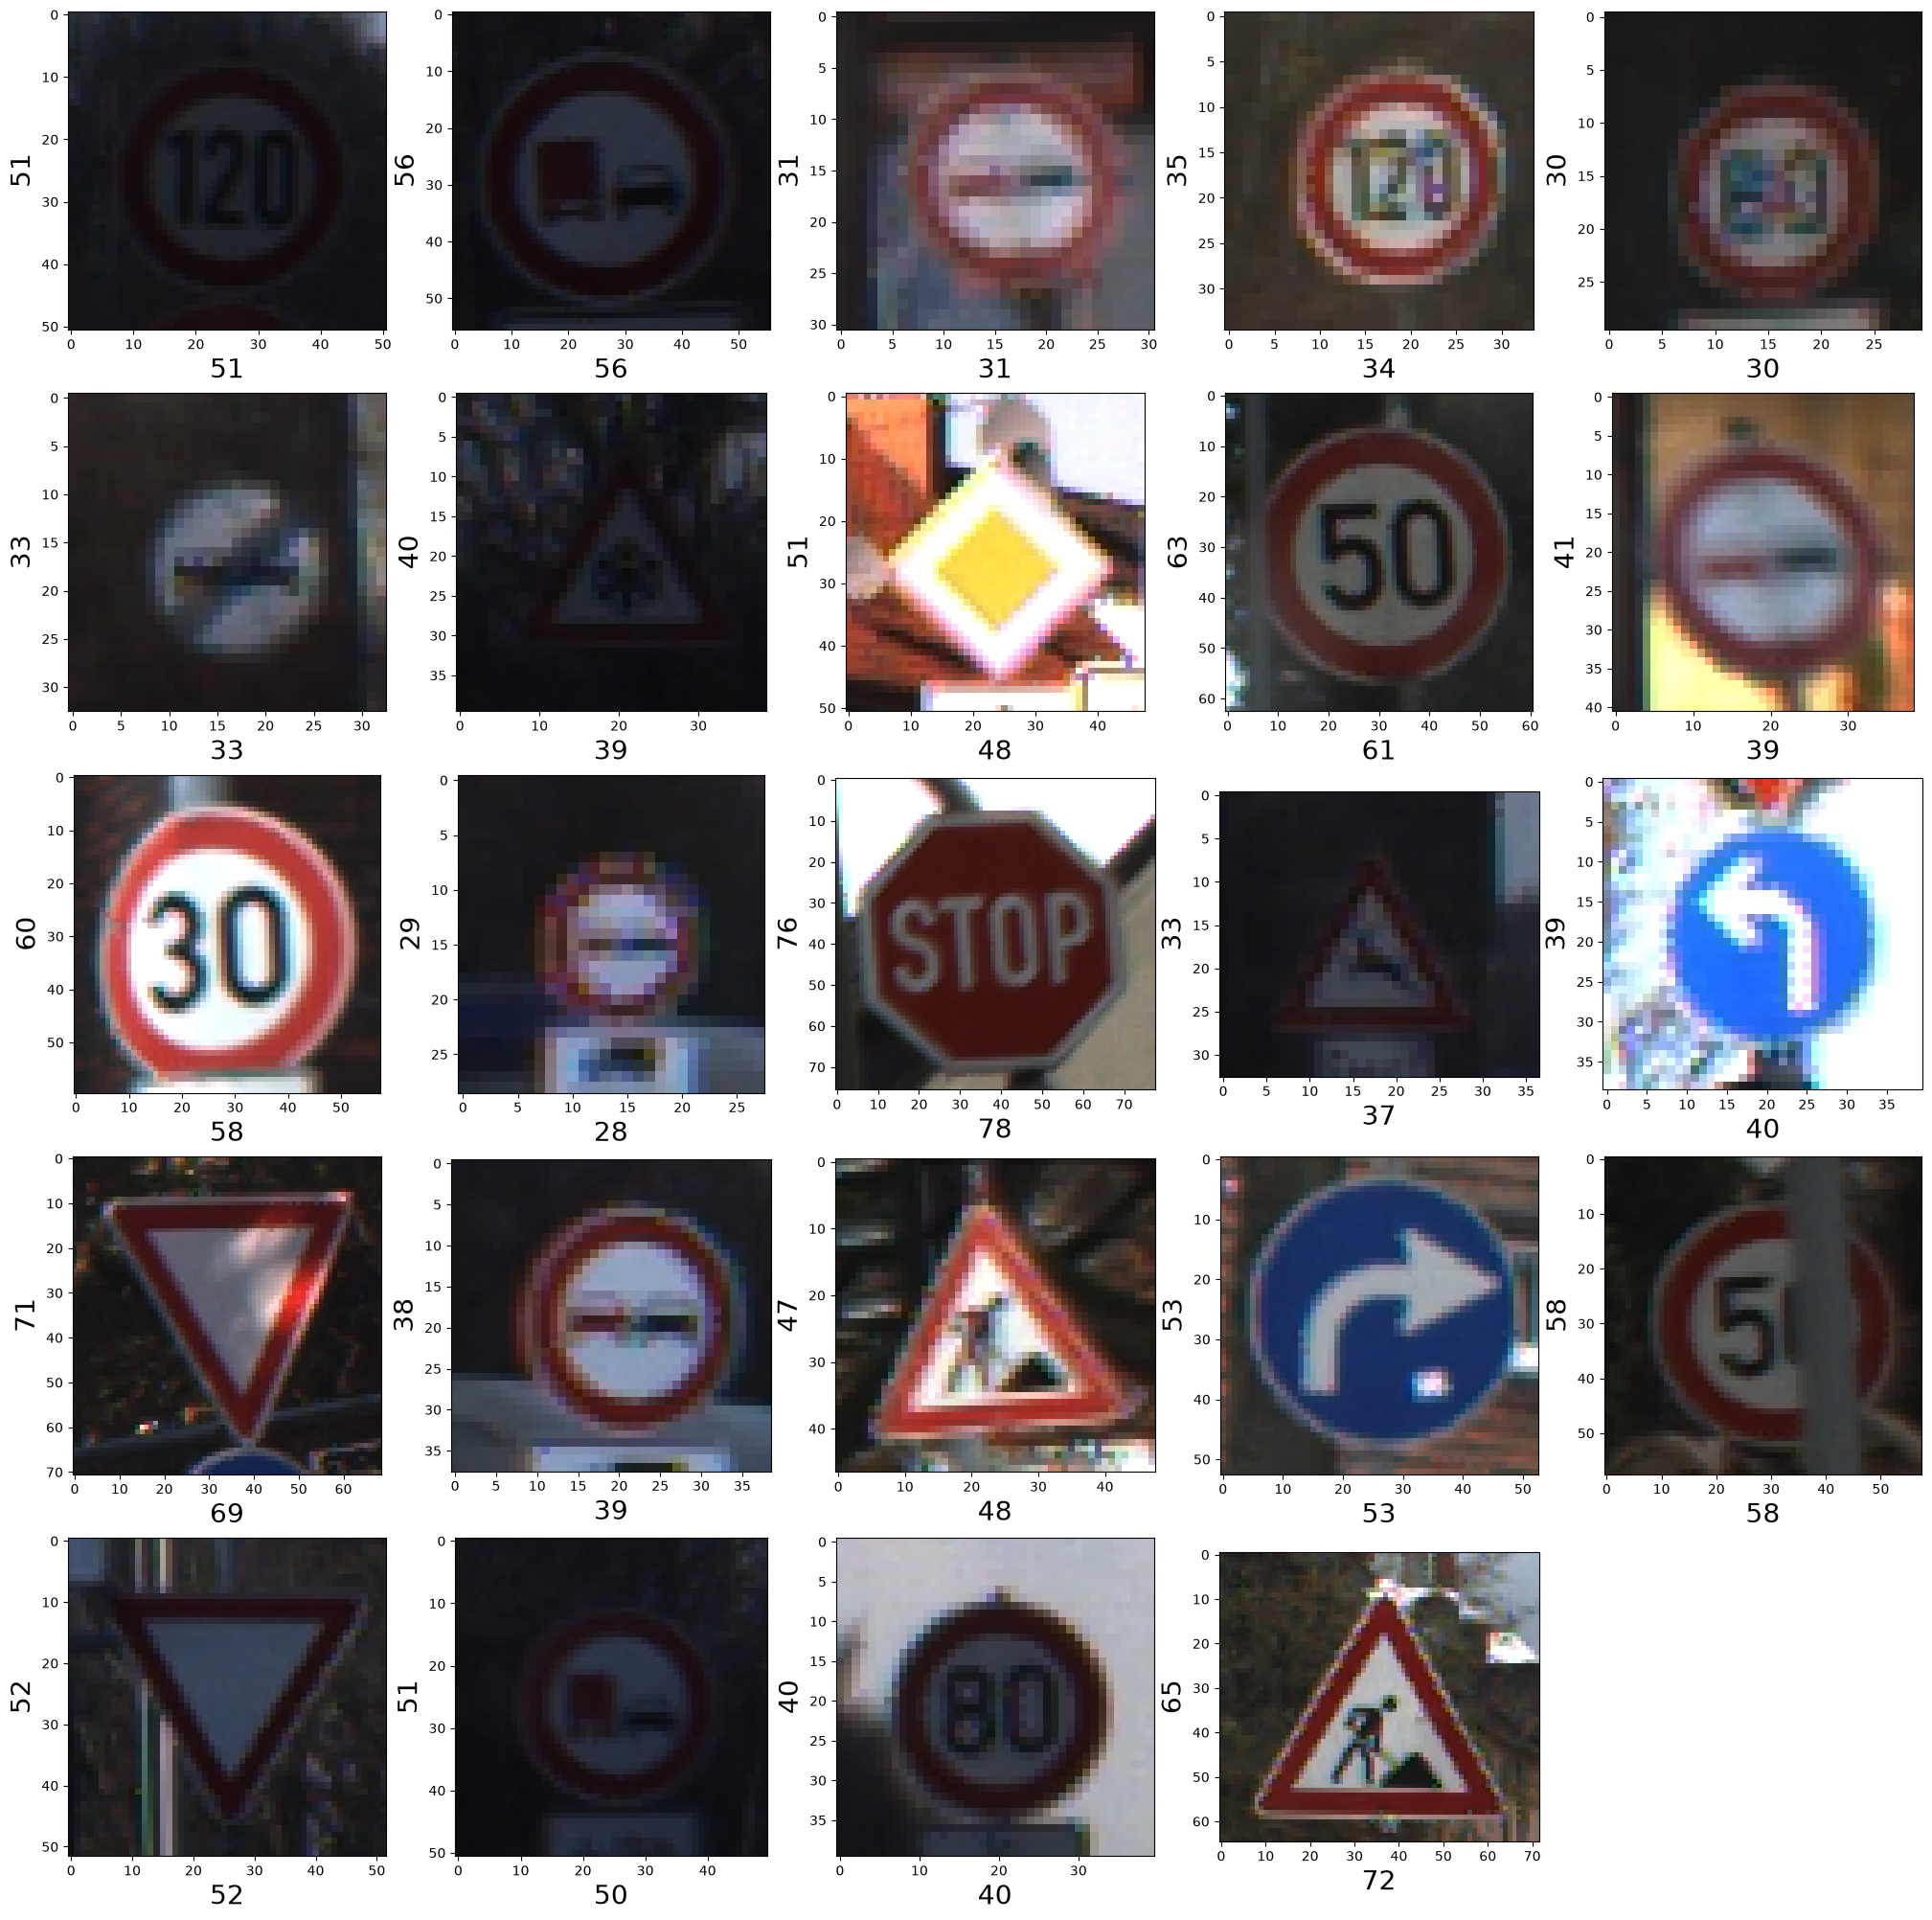

In [5]:
image_paths = os.listdir(test_dir)
plt.figure(figsize=(25, 25))

for i in range(1, 25):
    plt.subplot(5, 5, i)
    random_image_path = test_dir + "/" + random.choice(image_paths)
    random_image = imread(random_image_path)
    plt.imshow(random_image)
    plt.xlabel(random_image.shape[1], fontsize=20)
    plt.ylabel(random_image.shape[0], fontsize=20)

In [7]:
images = []
labels = []
image_shape = (50, 50)

for i in range(43):
    image_dir = train_dir + "/{0}".format(i)
    image_paths = os.listdir(image_dir)
    for image_path in image_paths:
        image = Image.open(image_dir + "/" + image_path)
        image = image.resize(image_shape)
        image = np.array(image)
        images.append(image)
        labels.append(i)

images = np.array(images)

In [10]:
labels = np.array(labels)
print(labels.shape)
print(images.shape)

(39209,)
(39209, 50, 50, 3)


In [2]:
def preprocessing_dataset(X, y = None):
    X = 0.299 * X[:, :, :, 0] + 0.587 * X[:, :, :, 1] + 0.114 * X[:, :, :, 2]
    X = (X / 255.).astype(np.float32)
    for i in range(X.shape[0]):
        X[i] = exposure.equalize_adapthist(X[i])
    if y is not None:
        y = np.eye(43)[y]
        X, y = shuffle(X, y)
    X = X.reshape(X.shape + (1,))
    return X, y

### Augmentation

In [3]:
from skimage.transform import rotate
from skimage.transform import warp
from skimage.transform import ProjectiveTransform

In [4]:
def flip_extend(X, y):
    horizontally_flippable = np.array([11, 12, 13, 15, 17, 18, 22, 26, 30, 35])
    vertically_flippable = np.array([1, 5, 12, 15, 17])
    both_flippable = np.array([32, 40])
    cross_flippable = np.array([
        [19, 20], 
        [33, 34], 
        [36, 37], 
        [38, 39],
        [20, 19], 
        [34, 33], 
        [37, 36], 
        [39, 38],
    ])
    n_classes = 43
    X_extend = np.empty([0, X.shape[1], X.shape[2], X.shape[3]], dtype = X.dtype)
    y_extend = np.empty([0], dtype = y.dtype)
    for c in range(n_classes):
        X_extend = np.append(X_extend, X[y==c], axis=0)
        if c in horizontally_flippable:
            X_extend = np.append(X_extend, X[y==c][:, :, ::-1, :], axis=0)
        if c in cross_flippable[:, 0]:
            flip_class = cross_flippable[cross_flippable[:, 0] == c][0][1]
            X_extend = np.append(X_extend, X[y==flip_class][:, :, ::-1, :], axis=0)
        y_extend = np.append(y_extend, np.full((X_extend.shape[0] - y_extend.shape[0]), c, dtype=int))
        if c in vertically_flippable:
            X_extend = np.append(X_extend, X_extend[y_extend == c][:, ::-1, :, :], axis=0)
        y_extend = np.append(y_extend, np.full((X_extend.shape[0] - y_extend.shape[0]), c, dtype=int))
        if c in both_flippable:
            X_extend = np.append(X_extend, X_extend[y_extend == c][:, ::-1, ::-1, :], axis=0)
        y_extend = np.append(y_extend, np.full((X_extend.shape[0] - y_extend.shape[0]), c, dtype=int))
    return (X_extend, y_extend)

In [ ]:
def apply_rotate(X, intensity):
    for i in range(X.shape[0]):
        delta = 30 * intensity
        X[i] = rotate(X[i], np.random.uniform(-delta, delta), mode="edge")
    return X

In [1]:
def apply_projection(X, intensity):
    image_size = X.shape[1]
    delta = image_size * 0.3 * intensity
    for i in range(X.shape[0]):
        tl_top = np.random.uniform(-d, d)
        tl_left = np.random.uniform(-d, d)
        bl_bottom = np.random.uniform(-d, d)
        bl_left = np.random.uniform(-d, d)
        tr_top = np.random.uniform(-d, d)
        tr_right = np.random.uniform(-d, d)
        br_bottom = np.random.uniform(-d, d)
        br_right = np.random.uniform(-d, d)
        transform = ProjectiveTransform()
        transform.from_estimate(
            np.array((
                (tl_left, tl_top),
                (bl_left, image_size - bl_bottom),
                (image_size - br_right, image_size - br_bottom),
                (image_size - tr_right, tr_top)
            )),
            np.array((
                (0, 0),
                (0, image_size),
                (image_size, image_size),
                (image_size, 0)
            )))
        X[i] = warp(X[1], transform, output_shape=(image_size, image_size), order=1, mode="edge")
    return X
